<a href="https://colab.research.google.com/github/GiannisAnte/credit-scoring-case/blob/dev/credit_scoring_case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install catboost shap -q
!pip install pandas -q

In [2]:
!wget -q https://raw.githubusercontent.com/jalajthanaki/credit-risk-modelling/master/data/cs-training.csv

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cs-training.csv", index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Описание признаков

150 000 заёмщиков, задача бинарной классификации: предсказать дефолт в течение 2 лет.

| Колонка | Описание |
|---|---|
| `SeriousDlqin2yrs` | **Целевая переменная.** 1 — заёмщик вышел на просрочку 90+ дней в течение 2 лет (дефолт), 0 — нет |
| `RevolvingUtilizationOfUnsecuredLines` | Утилизация возобновляемых необеспеченных кредитных линий (кредитки, овердрафты) — отношение текущего долга к лимиту |
| `age` | Возраст заёмщика |
| `NumberOfTime30-59DaysPastDueNotWorse` | Сколько раз за 2 года была просрочка 30-59 дней (но не хуже) |
| `DebtRatio` | Долговая нагрузка: (платежи по долгам + алименты + расходы на жильё) / месячный доход |
| `MonthlyIncome` | Месячный доход |
| `NumberOfOpenCreditLinesAndLoans` | Количество открытых кредитных линий и займов (кредитки + кредиты на авто, ипотеку и т.д.) |
| `NumberOfTimes90DaysLate` | Сколько раз была просрочка 90+ дней (самая тяжёлая категория) |
| `NumberRealEstateLoansOrLines` | Количество ипотек/кредитов под залог недвижимости |
| `NumberOfTime60-89DaysPastDueNotWorse` | Сколько раз была просрочка 60-89 дней |
| `NumberOfDependents` | Количество иждивенцев (не считая самого заёмщика) |

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


**LOAD TO SQLITE, check with first request**

In [12]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("borrowers", conn, index=True, index_label="borrower_id", if_exists="replace")

150000

In [15]:
query = """
SELECT
    AVG(age) AS avg_age,
    AVG(SeriousDlqin2yrs) AS default_rate,
    COUNT(*) AS n_borrowers
FROM borrowers
"""
result = pd.read_sql(query, conn)
result

,avg_age,default_rate,n_borrowers
0,52.295207,0.06684,150000


# Небольшая справочная таблица с возрастными диапазонами

In [16]:
age_bands = pd.DataFrame({
    "band_id": [1, 2, 3, 4, 5],
    "age_from": [18, 30, 45, 60, 75],
    "age_to":   [29, 44, 59, 74, 120],
    "age_band": ["18-29", "30-44", "45-59", "60-74", "75+"],
})
age_bands.to_sql("age_bands", conn, index=False, if_exists="replace")

5

In [19]:
join_query = """
SELECT
    b.borrower_id,
    b.age,
    ab.age_band,
    b.MonthlyIncome
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
"""
result = pd.read_sql(join_query, conn)
result

,borrower_id,age,age_band,MonthlyIncome
0,1,45,45-59,9120.0
1,2,40,30-44,2600.0
2,3,38,30-44,3042.0
3,4,30,30-44,3300.0
4,5,49,45-59,63588.0
...,...,...,...,...
149994,149996,74,60-74,2100.0
149995,149997,44,30-44,5584.0
149996,149998,58,45-59,NaN
149997,149999,30,30-44,5716.0


In [21]:
#ИЩЕМ АНОМАЛЬНОГО ЗАЕМЩИКА (В ПРЕДЫДУЩЕМ JOIN НЕТ ОДНОЙ ЗАПИСИ)
query = """
SELECT *
FROM borrowers
WHERE age < 18
"""
anomaly = pd.read_sql(query, conn)
anomaly

,borrower_id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


**Вывод:** JOIN с `age_bands` отфильтровал одну аномальную запись (age=0) -
149 999 строк вместо 150 000, что и обнаружило проблему в данных.

# SQL: сравниваем доход внутри возрастной **группы**
- Выше сделали join с таблицей `age_bands` -  узнали возрастную группу каждого заёмщика
- Дальше нужно **отдельно внутри каждой возрастной группы** отсортировать людей
   по доходу и присвоить каждому номер места - 1-й, 2-й, 3-й и так далее.

In [22]:
query = """
SELECT
    b.borrower_id,
    b.age,
    ab.age_band,
    b.MonthlyIncome,
    RANK() OVER (PARTITION BY ab.age_band ORDER BY b.MonthlyIncome DESC) AS income_rank_in_age_band
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
"""
group_query = pd.read_sql(query, conn)
group_query

,borrower_id,age,age_band,MonthlyIncome,income_rank_in_age_band
0,36716,29,18-29,159791.0,1
1,57095,28,18-29,82083.0,2
2,79710,28,18-29,50000.0,3
3,76219,26,18-29,43000.0,4
4,76231,25,18-29,36000.0,5
...,...,...,...,...,...
149994,149855,75,75+,NaN,7650
149995,149916,76,75+,NaN,7650
149996,149919,77,75+,NaN,7650
149997,149977,76,75+,NaN,7650


**Вывод:**
Оконная функция `RANK()` корректно проставила место по доходу внутри
каждой возрастной группы; в группе 75+ видно, что у заёмщиков с пропущенным
доходом (NaN) всем присвоен одинаковый последний ранг - сигнал,
что `MonthlyIncome` нужно будет почистить перед обучением

## SQL: доля дефолтов по возрастным группам

В какой возрастной группе заёмщики чаще всего уходят в дефолт?
Для этого нужно **сгруппировать** всех заёмщиков по возрастной группе и
посчитать для каждой группы среднюю долю дефолтов (это `GROUP BY`),
а слабые группы с маленьким числом наблюдений - отбросить, чтобы не путать
случайный шум с реальным сигналом (`HAVING COUNT(*) > ...`).

In [24]:
query = """
SELECT
    ab.age_band,
    COUNT(*) AS n_borrowers,
    AVG(b.SeriousDlqin2yrs) AS default_rate
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
GROUP BY ab.age_band
HAVING COUNT(*) > 100
"""
default_rate_query = pd.read_sql(query, conn)
default_rate_query

,age_band,n_borrowers,default_rate
0,18-29,8820,0.117347
1,30-44,38982,0.094916
2,45-59,53879,0.070361
3,60-74,36948,0.034400
4,75+,11370,0.020141


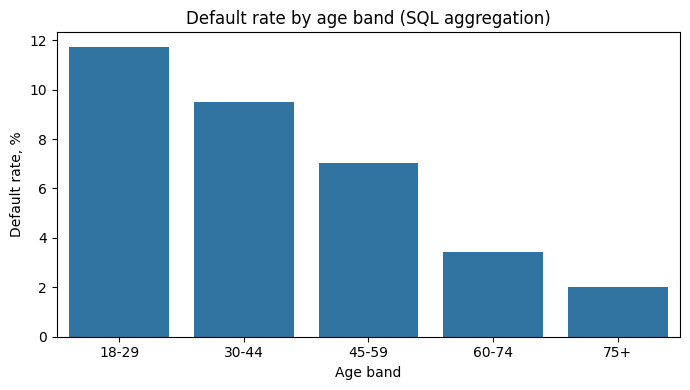

In [28]:
default_rate_query["default_rate_pct"] = default_rate_query["default_rate"] * 100

fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=default_rate_query, x="age_band", y="default_rate_pct", ax=ax)
ax.set_title("Default rate by age band (SQL aggregation)")
ax.set_ylabel("Default rate, %")
ax.set_xlabel("Age band")
plt.tight_layout()
plt.show()

**Вывод**: чем старше заёмщик, тем реже он уходит в дефолт. У самых молодых (18–29 лет) дефолт случается в 11.7% случаев, а у самых старших (75+) — только в 2.0%. То есть молодые попадают в дефолт почти в 6 раз чаще. Значит, уже по одному возрасту видно, что это важный признак риска — ещё до того, как мы построим модель.

# EDA

In [48]:
df = pd.read_sql("SELECT * FROM borrowers", conn, index_col="borrower_id")

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [50]:
missing = pd.DataFrame({"count": df.isna().sum(),"percent": df.isna().mean() * 100})

missing

,count,percent
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
MonthlyIncome,29731,19.820667
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0,0.000000


In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


## Удаление аномальной записи (age=0)

Проверили запись с `age=0` вручную - независимо от значений остальных
признаков, возраст 0 физически недостоверен. Это единственная такая строка
из 150 000, поэтому удаление не повлияет на статистику модели - удаляем.

In [52]:
df = df[df["age"] > 0]

## Пропуски в MonthlyIncome
Около 20% значений пропущено. Удалять столько строк нельзя, поэтому заполняем пропуски медианой. Она лучше среднего подходит для дохода, потому что меньше зависит от больших значений и выбросов. Дополнительно создадим отдельный признак, показывающий, что доход был пропущен - возможно, сам факт отсутствия этой информации связан с риском дефолта.


In [53]:
df["MonthlyIncome_was_missing"] = df["MonthlyIncome"].isna().astype(int)
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

### Пропуски в NumberOfDependents

Около 2.6% значений пропущено. Сначала проверим, отличается ли уровень дефолтов у клиентов с пропущенным значением от клиентов, у которых число иждивенцев указано. Если разница небольшая, для простоты заменим пропуски на 0.


In [54]:
print("Пропущено:", df[df["NumberOfDependents"].isna()]["SeriousDlqin2yrs"].mean())
print("Не пропущено:", df[df["NumberOfDependents"].notna()]["SeriousDlqin2yrs"].mean())

Пропущено: 0.04561671763506626
Не пропущено: 0.06741057675851446


Проверим, связан ли сам факт пропуска с дефолтом.

Гипотезы:

* H0: наличие пропуска в NumberOfDependents не связано с дефолтом.
* H1: наличие пропуска в NumberOfDependents связано с дефолтом.

Для проверки используем χ²-тест независимости.

In [58]:
temp_t = pd.crosstab(
    df["NumberOfDependents"].isna(),
    df["SeriousDlqin2yrs"]
)
temp_t

SeriousDlqin2yrs,0,1
NumberOfDependents,,
False,136228,9847
True,3745,179


In [59]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(temp_t)

print("chi2:", chi2)
print("p-value:", p_value)

chi2: 28.75140658613835
p-value: 8.229013222139592e-08


Получили:

* χ² = 28.75
* p-value = 8.23 × 10⁻⁸

Так как p-value значительно меньше 0.05, отвергаем H0. Значит, в наших данных есть статистически значимая связь между наличием пропуска в NumberOfDependents и дефолтом.

Поэтому не будем просто терять информацию о пропуске: заменим NaN на 0 и дополнительно создадим отдельный признак, показывающий, было ли значение пропущено.

In [61]:
df["NumberOfDependents_missing"] = df["NumberOfDependents"].isna().astype(int)
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149999 entries, 1 to 150000
Data columns (total 13 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149999 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149999 non-null  float64
 2   age                                   149999 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149999 non-null  int64  
 4   DebtRatio                             149999 non-null  float64
 5   MonthlyIncome                         149999 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149999 non-null  int64  
 7   NumberOfTimes90DaysLate               149999 non-null  int64  
 8   NumberRealEstateLoansOrLines          149999 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149999 non-null  int64  
 10  NumberOfDependents                    149999 non-null  float64
 11  Month